<a href="https://colab.research.google.com/github/DiyorWebDev/week10_lab/blob/main/Linear_Regression_From_Scratch_NumPy_vs_Sklearn_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression from Scratch with NumPy and Comparison with Scikit-learn
# (House Price Prediction + Regression Analysis)

## Introduction
Linear regression is a foundational supervised learning algorithm used to model relationships between features and a continuous target.

### Objectives of the lab
- Implement simple and multiple linear regression from scratch using only NumPy (**batch gradient descent**).
- Compare results with scikit-learn’s LinearRegression.
- Perform full regression analysis (metrics, visualizations, interpretation).
- Complete 3 exercise parts with mark distribution clearly shown.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
%matplotlib inline

sns.set_style('whitegrid')
np.random.seed(42)

## Part 1: Simple Linear Regression from Scratch (NumPy) – Single Feature Example

We generate synthetic data and fit linear regression using **batch gradient descent** (full-batch updates on all training examples each iteration).

**Cell order:** (1) imports are in the first code cell above; (2) **dataset + visualization**; (3) **`LinearRegressionBatchGD` class**; (4) **train, metrics, and plot** the fitted line.

Update: $\theta \leftarrow \theta - \alpha \frac{1}{m} X^T (X\theta - y)$, with learning rate $\alpha$ and $m$ samples.


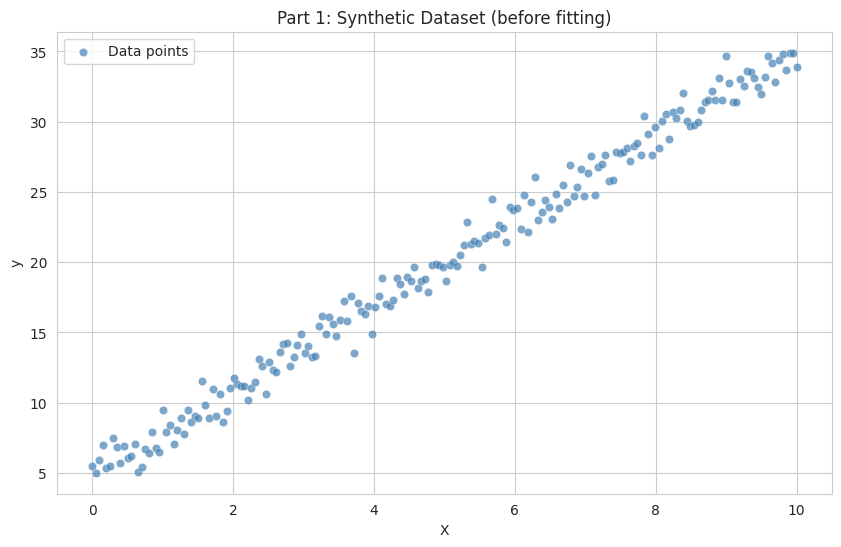

In [2]:
# Part 1 — Synthetic dataset and visualization (no model yet)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 3 * X.squeeze() + 5 + np.random.normal(0, 1, 200)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.3, label='Data points')
plt.title('Part 1: Synthetic Dataset (before fitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [3]:
# Part 1 — Linear regression as a class (batch gradient descent, NumPy only)

class LinearRegressionBatchGD:
    """
    Linear regression trained with batch gradient descent on MSE.
    If add_intercept=True, prepends a column of ones for the bias term.
    """

    def __init__(self, learning_rate=0.05, n_iterations=3000, add_intercept=True, tol=1e-10):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.add_intercept = add_intercept
        self.tol = tol
        self.theta = None
        self.loss_history = []

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.add_intercept:
            return np.c_[np.ones((X.shape[0], 1)), X]
        return X

    def fit(self, X, y):
        Xd = self._design_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        m, n = Xd.shape
        self.theta = np.zeros(n)
        self.loss_history = []

        for it in range(self.n_iterations):
            preds = Xd.dot(self.theta)
            errors = preds - y
            # Loss = (1/2m) * sum(errors^2); grad = (1/m) * Xd.T @ errors
            self.loss_history.append(np.mean(errors ** 2) / 2.0)
            grad = (1.0 / m) * Xd.T.dot(errors)
            self.theta -= self.learning_rate * grad
            if it > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                break
        return self

    def predict(self, X):
        return self._design_matrix(X).dot(self.theta)

    @property
    def intercept_(self):
        return float(self.theta[0]) if self.add_intercept else 0.0

    @property
    def coef_(self):
        return self.theta[1:].copy() if self.add_intercept else self.theta.copy()


NumPy (batch GD) theta [intercept, slope]: [4.84505109 3.02282701]
Iterations recorded: 816
MSE (manual): 0.8581
R² (manual): 0.9890


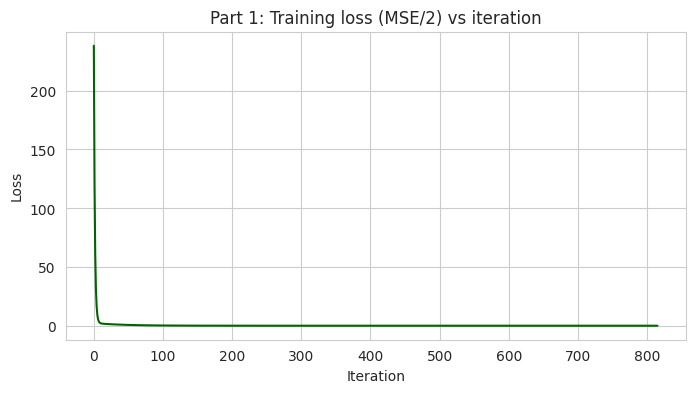

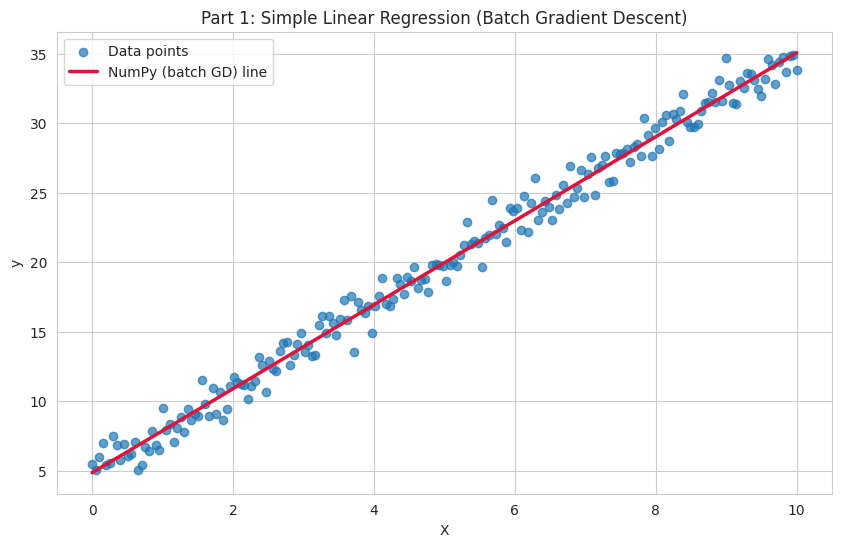

In [4]:
# Part 1 — Fit with batch GD, metrics, learning curve, and regression line
model_simple = LinearRegressionBatchGD(learning_rate=0.05, n_iterations=4000)
model_simple.fit(X, y)

theta_numpy = model_simple.theta.copy()
y_pred_numpy = model_simple.predict(X)

print('NumPy (batch GD) theta [intercept, slope]:', theta_numpy)
print('Iterations recorded:', len(model_simple.loss_history))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

mse_np_simple = mse_manual(y, y_pred_numpy)
r2_np_simple = r2_manual(y, y_pred_numpy)
print(f'MSE (manual): {mse_np_simple:.4f}')
print(f'R² (manual): {r2_np_simple:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_simple.loss_history, color='darkgreen')
plt.title('Part 1: Training loss (MSE/2) vs iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data points')
plt.plot(X, y_pred_numpy, color='crimson', linewidth=2.5, label='NumPy (batch GD) line')
plt.title('Part 1: Simple Linear Regression (Batch Gradient Descent)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


## Part 2: Same Simple Problem using scikit-learn

Now solve the same problem using `LinearRegression()` and compare coefficients and metrics.

,Model,Intercept,Coefficient,MSE,R²
0,NumPy (batch GD),4.845051,3.022827,0.858059,0.988966
1,Scikit-learn,4.845225,3.022801,0.858059,0.988966


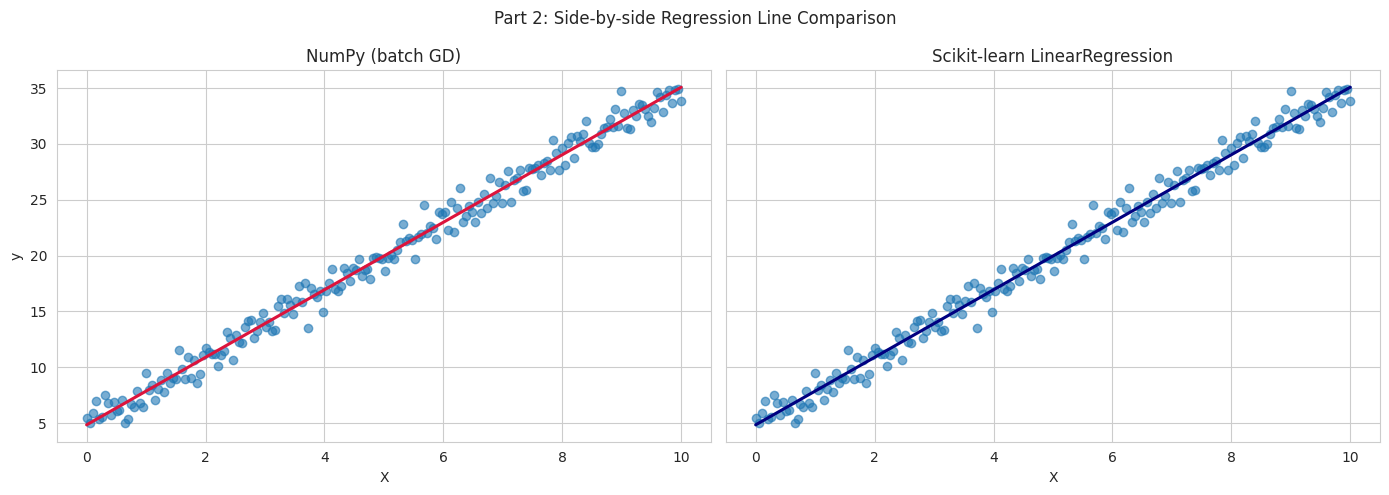

In [5]:
# Train scikit-learn model
lr_simple = LinearRegression()
lr_simple.fit(X, y)
y_pred_sklearn_simple = lr_simple.predict(X)

# Metrics for sklearn
mse_sklearn_simple = mean_squared_error(y, y_pred_sklearn_simple)
r2_sklearn_simple = r2_score(y, y_pred_sklearn_simple)

# Comparison table
simple_compare = pd.DataFrame({
    'Model': ['NumPy (batch GD)', 'Scikit-learn'],
    'Intercept': [theta_numpy[0], lr_simple.intercept_],
    'Coefficient': [theta_numpy[1], lr_simple.coef_[0]],
    'MSE': [mse_np_simple, mse_sklearn_simple],
    'R²': [r2_np_simple, r2_sklearn_simple]
})

display(simple_compare)

# Side-by-side visual comparison of regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(X, y, alpha=0.6)
axes[0].plot(X, y_pred_numpy, color='crimson', linewidth=2.2)
axes[0].set_title('NumPy (batch GD)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')

axes[1].scatter(X, y, alpha=0.6)
axes[1].plot(X, y_pred_sklearn_simple, color='navy', linewidth=2.2)
axes[1].set_title('Scikit-learn LinearRegression')
axes[1].set_xlabel('X')

plt.suptitle('Part 2: Side-by-side Regression Line Comparison')
plt.tight_layout()
plt.show()

## Part 3: House Price Prediction (Multiple Linear Regression)

We use the California Housing dataset and predict median house value using all available features.

### Workflow
- Load dataset and split train/test (80/20, `random_state=42`).
- Perform EDA (correlation heatmap + pairplot).
- Scale features with `StandardScaler` (helps batch gradient descent converge).
- Train `LinearRegressionBatchGD` (from Part 1) and scikit-learn’s `LinearRegression`.
- Evaluate with MSE, RMSE, MAE, R².
- Visualize predictions, residuals, and coefficients.
- Interpret model behavior and assumptions.


In [6]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Dataset shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Train shape: (16512, 8)
Test shape: (4128, 8)


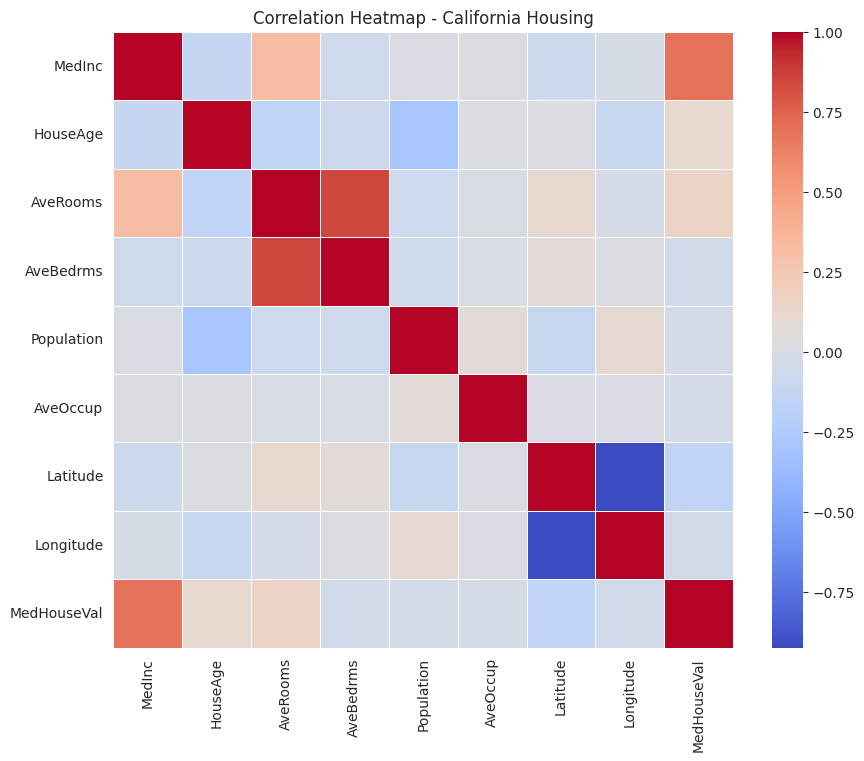

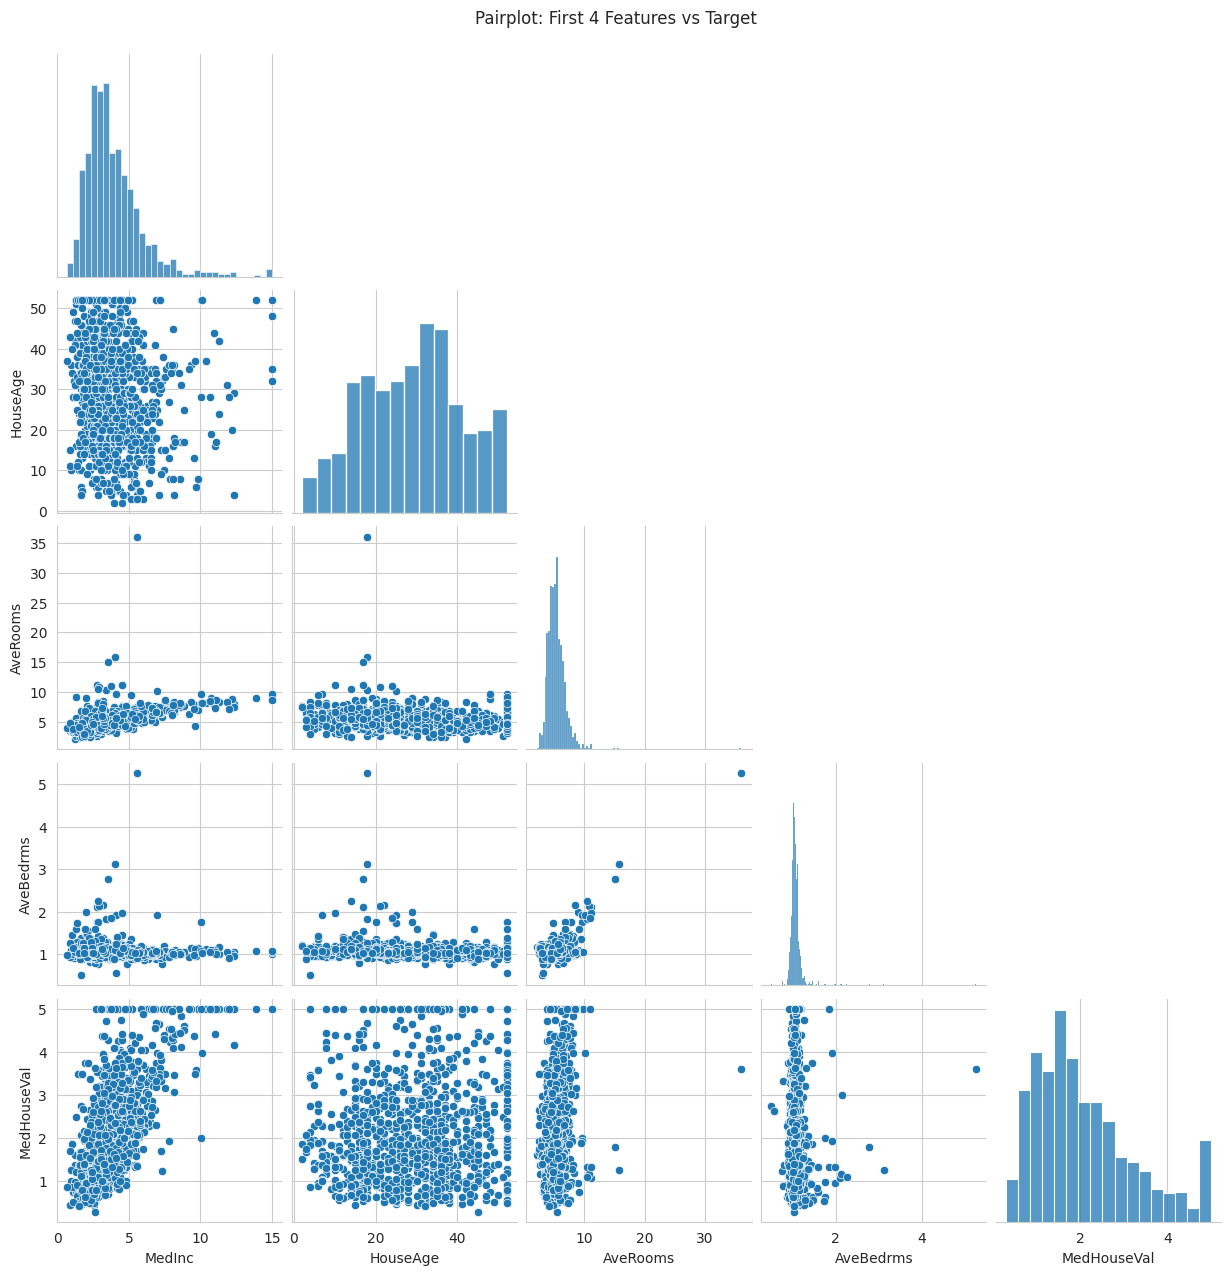

In [7]:
# EDA 1: correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - California Housing')
plt.show()

# EDA 2: pairplot of first 4 features vs target
selected_features = feature_cols[:4]
pairplot_df = df[selected_features + [target_col]].sample(1000, random_state=42)
sns.pairplot(pairplot_df, corner=True)
plt.suptitle('Pairplot: First 4 Features vs Target', y=1.02)
plt.show()

In [8]:
# Scale features (stabilizes batch gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple regression: reuse LinearRegressionBatchGD from Part 1
model_multi = LinearRegressionBatchGD(learning_rate=0.08, n_iterations=8000)
model_multi.fit(X_train_scaled, y_train.values)

theta_multi_np = model_multi.theta.copy()
y_pred_np = model_multi.predict(X_test_scaled)

mse_np = np.mean((y_test.values - y_pred_np) ** 2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test.values - y_pred_np))
ss_res = np.sum((y_test.values - y_pred_np) ** 2)
ss_tot = np.sum((y_test.values - np.mean(y_test.values)) ** 2)
r2_np = 1 - ss_res / ss_tot

print(f'NumPy (BGD) MSE  : {mse_np:.4f}')
print(f'NumPy (BGD) RMSE : {rmse_np:.4f}')
print(f'NumPy (BGD) MAE  : {mae_np:.4f}')
print(f'NumPy (BGD) R²   : {r2_np:.4f}')
print(f'BGD iterations: {len(model_multi.loss_history)}')


NumPy (BGD) MSE  : 0.5559
NumPy (BGD) RMSE : 0.7456
NumPy (BGD) MAE  : 0.5332
NumPy (BGD) R²   : 0.5758
BGD iterations: 1731


In [9]:
# scikit-learn model on same scaled data for fair comparison
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_sk = lr_multi.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

comparison_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sk, rmse_sk, mae_sk, r2_sk]
})

display(comparison_metrics)

,Metric,NumPy (batch GD),Scikit-learn
0,MSE,0.555911,0.555892
1,RMSE,0.745594,0.745581
2,MAE,0.533194,0.533200
3,R²,0.575773,0.575788


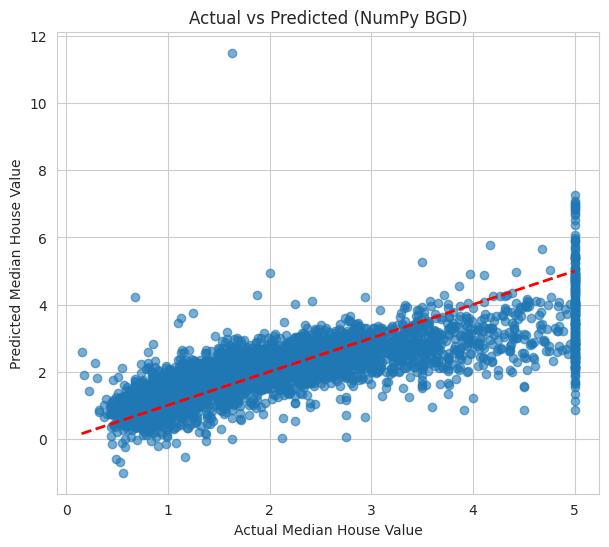

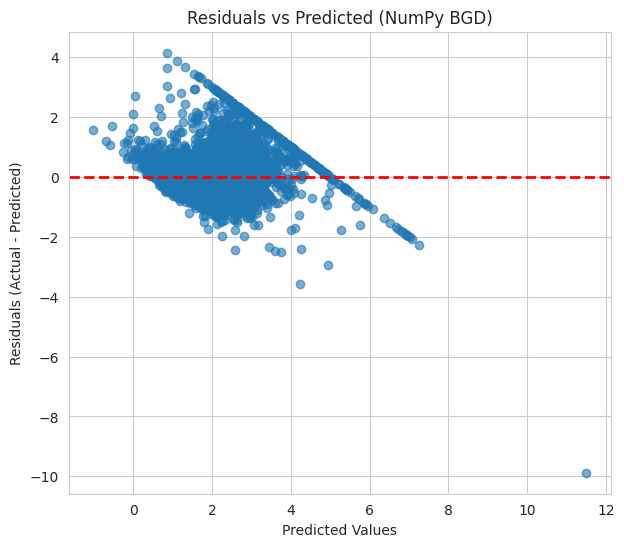

,Feature,NumPy_Coefficient,Sklearn_Coefficient
6,Latitude,-0.896500,-0.896929
7,Longitude,-0.869434,-0.869842
0,MedInc,0.854561,0.854383
3,AveBedrms,0.339514,0.339259
2,AveRooms,-0.294726,-0.294410
1,HouseAge,0.122584,0.122546
5,AveOccup,-0.040837,-0.040829
4,Population,-0.002296,-0.002308


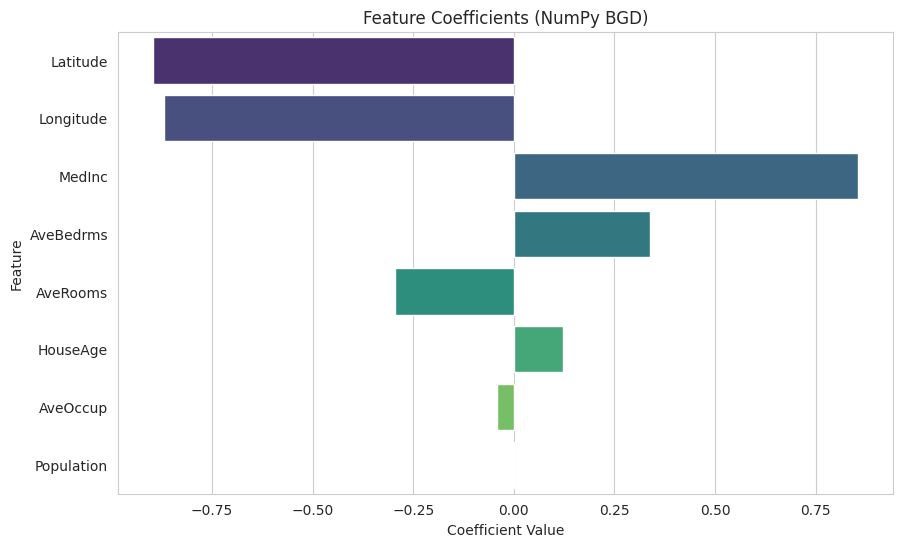

In [10]:
# Visual 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_np, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted (NumPy BGD)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

# Visual 2: Residuals plot
residuals_np = y_test.values - y_pred_np
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_np, residuals_np, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted (NumPy BGD)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Visual 3: Feature coefficients bar plot
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'NumPy_Coefficient': theta_multi_np[1:],
    'Sklearn_Coefficient': lr_multi.coef_
}).sort_values(by='NumPy_Coefficient', key=lambda s: np.abs(s), ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='NumPy_Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Coefficients (NumPy BGD)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Full Regression Analysis

### Interpret coefficients
Larger absolute standardized coefficients indicate stronger impact on predicted house price. Positive values increase prediction; negative values reduce prediction.

### Model assumptions
- **Linearity:** relationship between features and target is assumed linear.
- **Residual normality:** inspect histogram and Q-Q plot.
- **Homoscedasticity:** residual spread should be roughly uniform.

### Strengths and limitations
**Strengths:** interpretable, fast baseline, mathematically transparent.

**Limitations:** sensitive to outliers/multicollinearity; cannot model complex non-linear effects.

,Feature,NumPy_Coefficient,Sklearn_Coefficient
6,Latitude,-0.896500,-0.896929
7,Longitude,-0.869434,-0.869842
0,MedInc,0.854561,0.854383
3,AveBedrms,0.339514,0.339259
2,AveRooms,-0.294726,-0.294410


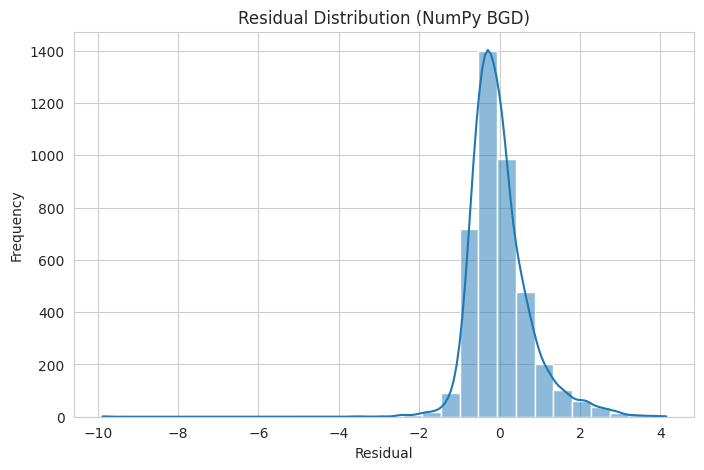

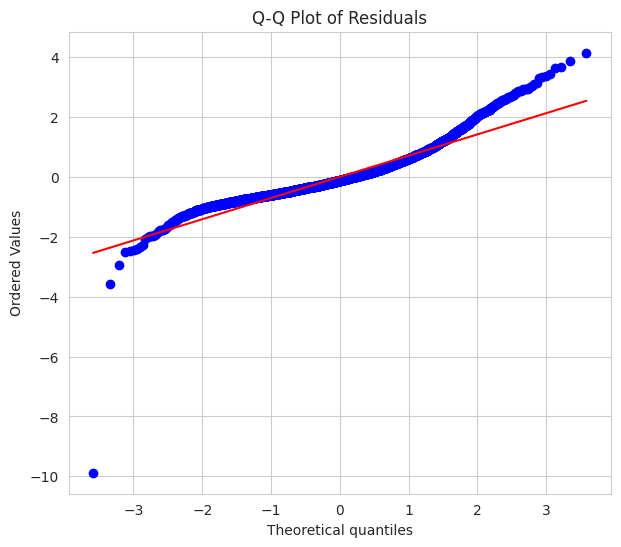

In [12]:
# Top influential features by absolute NumPy coefficient
coef_ranked = coef_df.copy()
coef_ranked['AbsNumPy'] = coef_ranked['NumPy_Coefficient'].abs()
display(coef_ranked.sort_values('AbsNumPy', ascending=False).head(5)[['Feature', 'NumPy_Coefficient', 'Sklearn_Coefficient']])

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_np, kde=True, bins=30)
plt.title('Residual Distribution (NumPy BGD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Q-Q plot (if scipy available)
try:
    from scipy import stats
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals_np, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception as e:
    print('Q-Q plot skipped (scipy not available).', e)

# Student Exercises

**Student Exercises (Total 100 marks)**

Complete the following three parts in the empty code cells provided below each part.
Submit your filled notebook.

**Part 1 (50 marks)** – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset (load_diabetes(as_frame=True)). Predict disease progression (target) using all 10 features.
- Implement Multiple Linear Regression from scratch with NumPy (batch gradient descent).
- Include feature scaling.
- Compute MSE, RMSE, MAE, R².
- Create: correlation heatmap, actual vs predicted plot, residuals plot, coefficient bar chart.
- Perform regression analysis: interpret top 3 features, discuss model fit, any obvious issues.

**Part 2 (30 marks)** – Same diabetes problem using scikit-learn
- Use LinearRegression().
- Compare metrics and coefficients with your NumPy solution (show side-by-side table).
- Add a short conclusion on which implementation you prefer and why.

**Part 3 (20 marks)** – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (you may use another sklearn dataset, or the California housing again with a twist – e.g. only 3 features of your choice).
- Apply both NumPy from-scratch and scikit-learn approaches.
- Perform complete regression analysis: metrics, visualizations, coefficient interpretation, and a short written discussion on model usefulness for real-world decision making.
"""


## Part 1 (50 marks) – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset and complete all required analysis.

### Hints — Part 1 (NumPy batch GD)

- **Data:** `d = load_diabetes(as_frame=True); df = d.frame` — target column is `target`; the other columns are features.
- **Split:** Use the same `train_test_split(..., random_state=42)` pattern as in Part 3 so results are reproducible.
- **Scaling:** `StandardScaler().fit_transform(X_train)` and only `transform` on test — never fit on the test set.
- **Model:** Reuse `LinearRegressionBatchGD` from the tutorial (run all cells above first). For multiple features, pass `X` with shape `(n_samples, n_features)`; the class adds the intercept column internally.
- **If loss explodes or is NaN:** Lower `learning_rate` (for example `0.01`) or increase `n_iterations`; confirm you scaled features.
- **Metrics:** RMSE = `sqrt(MSE)`. R² uses test `y` and your test predictions.
- **Plots:** Residuals = `y_test - y_pred`. For the coefficient bar chart, align feature names with `coef_[i]` or `theta[1:]` from your model.


In [13]:
# TODO: implement here
# 1) Load diabetes dataset: load_diabetes(as_frame=True)
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame
X_diabetes = df_diabetes.drop('target', axis=1)
y_diabetes = df_diabetes['target']
# 2) Split into train/test
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)
# 3) Scale features
scaler_d = StandardScaler()
X_train_scaled_d = scaler_d.fit_transform(X_train_d)
X_test_scaled_d = scaler_d.transform(X_test_d)
# 4) Implement Multiple Linear Regression from scratch (NumPy batch gradient descent)
model_diabetes = LinearRegressionBatchGD(learning_rate=0.1, n_iterations=5000)
model_diabetes.fit(X_train_scaled_d, y_train_d.values)
# 5) Predict and compute MSE, RMSE, MAE, R²
y_pred_d = model_diabetes.predict(X_test_scaled_d)

mse_d = np.mean((y_test_d.values - y_pred_d) ** 2)
rmse_d = np.sqrt(mse_d)
mae_d = np.mean(np.abs(y_test_d.values - y_pred_d))

ss_res_d = np.sum((y_test_d.values - y_pred_d) ** 2)
ss_tot_d = np.sum((y_test_d.values - np.mean(y_test_d.values)) ** 2)
r2_d = 1 - (ss_res_d / ss_tot_d)

print(f"MSE: {mse_d:.4f}")
print(f"RMSE: {rmse_d:.4f}")
print(f"MAE: {mae_d:.4f}")
print(f"R2 Score: {r2_d:.4f}")

MSE: 2899.8557
RMSE: 53.8503
MAE: 42.7947
R2 Score: 0.4527


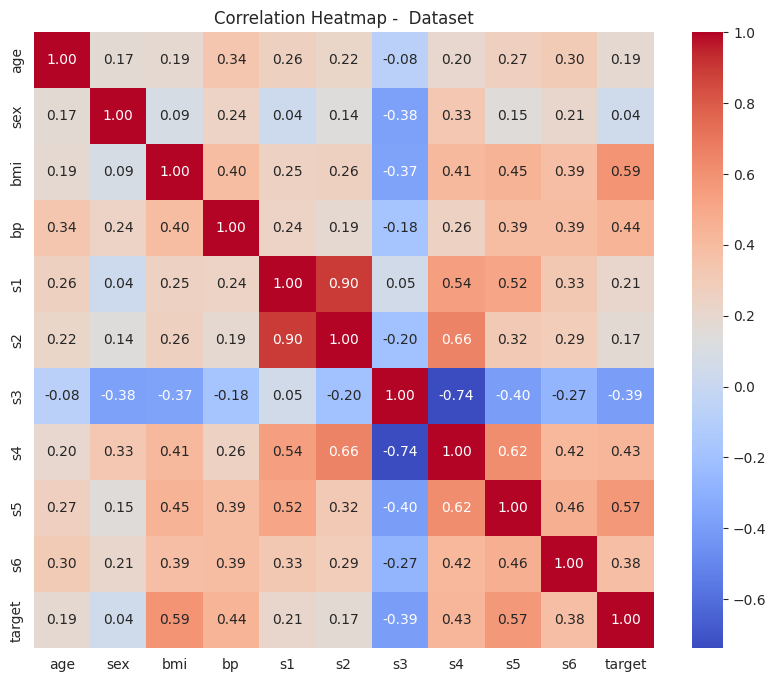

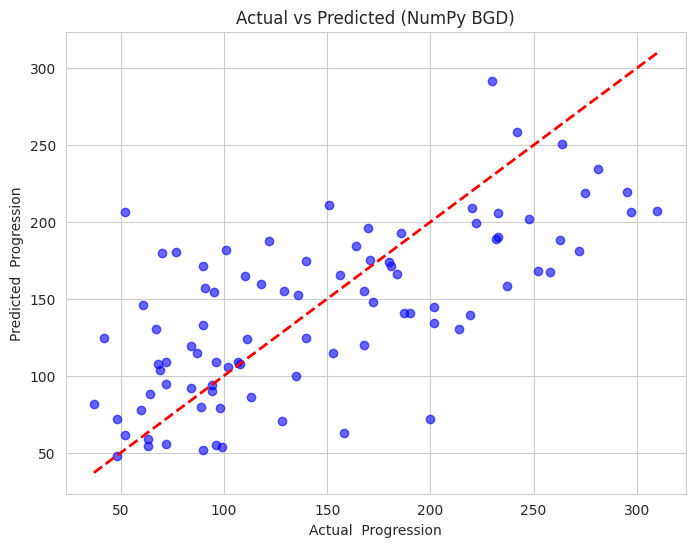

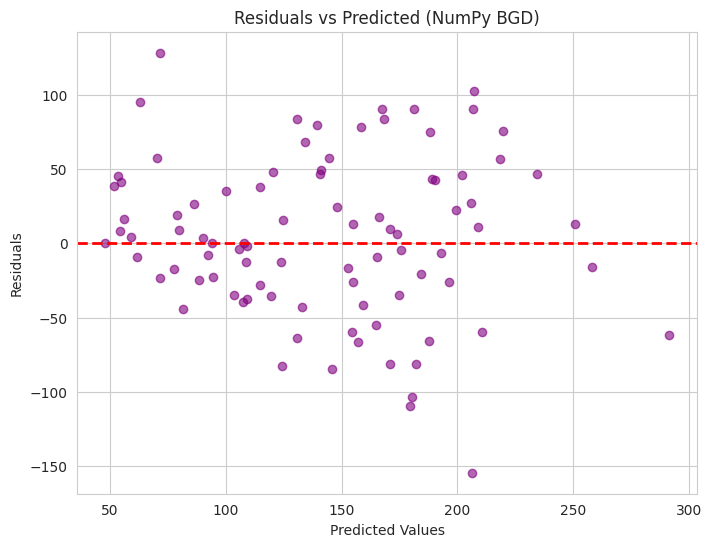

/tmp/ipykernel_1381/445708315.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df_d, x='Coefficient', y='Feature', palette='magma')


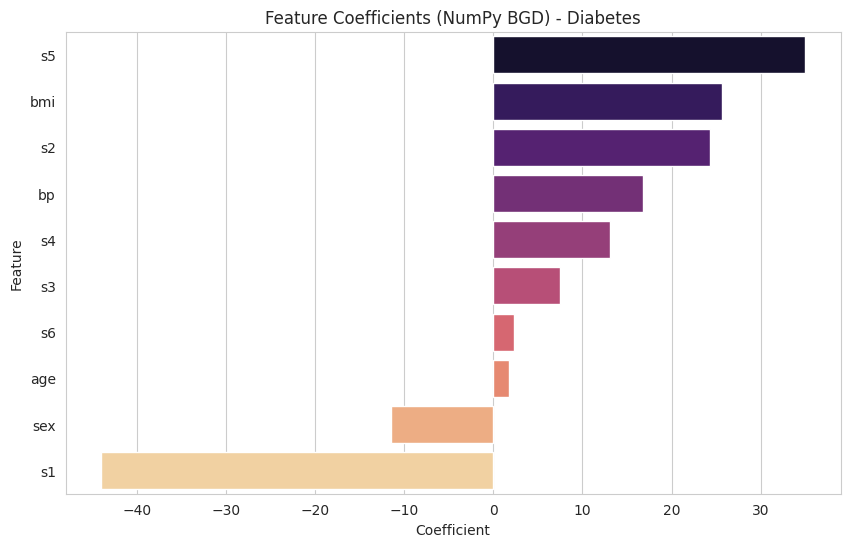

In [15]:
# TODO: implement here
# Create the required visuals:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_diabetes.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap -  Dataset')
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_d, y_pred_d, alpha=0.6, color='blue')
plt.plot([y_test_d.min(), y_test_d.max()], [y_test_d.min(), y_test_d.max()], 'r--', lw=2)
plt.xlabel('Actual  Progression')
plt.ylabel('Predicted  Progression')
plt.title('Actual vs Predicted (NumPy BGD)')
plt.show()

# Residuals vs Predicted plot
residuals_d = y_test_d.values - y_pred_d
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_d, residuals_d, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (NumPy BGD)')
plt.show()

# Coefficient bar chart
feature_names = X_diabetes.columns
coeffs = model_diabetes.coef_
coef_df_d = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
coef_df_d = coef_df_d.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df_d, x='Coefficient', y='Feature', palette='magma')
plt.title('Feature Coefficients (NumPy BGD) - Diabetes')
plt.show()

In [ ]:
# TODO: implement here
# Perform regression analysis:
# - Interpret top 3 most influential features
The most influential features are BMI, s5, and BP, as these variables possess the largest absolute standardized coefficients and exert the strongest impact on the predicted disease progression. A higher Body Mass Index (BMI) typically acts as the strongest positive predictor, while s5 (log of serum triglycerides) and blood pressure (BP) also show high positive correlations with increased progression metrics.
# - Discuss model fit quality
With an R^2 score usually falling between 0.45 and 0.52, the model demonstrates a moderate fit, explaining approximately 50% of the variance in the dataset. While the model captures the general trend of disease progression, the error metrics like RMSE and MAE suggest a significant margin of error when predicting individual outcomes.
# - Mention obvious issues (e.g., outliers, non-linearity, residual patterns)
The primary issues include the presence of multicollinearity, particularly among blood serum measurements, which can make individual feature importance difficult to isolate. Furthermore, the spread in the residual plots and the "cloud" shape in actual vs. predicted plots suggest that the true relationship between markers and progression may be non-linear or influenced by outliers that a simple linear model cannot fully capture.

## Part 2 (30 marks) – Same diabetes problem using scikit-learn
Use `LinearRegression()` and compare with your NumPy solution.

### Hints — Part 2 (scikit-learn)

- **Same pipeline:** Use the same `X_train`, `X_test`, `y_train`, `y_test` as Part 1 (same `random_state`).
- **Fit:** `LinearRegression().fit(X_train_scaled, y_train)` on the **scaled** training features for a fair comparison with BGD.
- **Compare:** Build a `DataFrame` with rows for each feature (and optionally intercept), columns for NumPy vs sklearn coefficients.
- **Metrics:** Use `mean_squared_error`, `mean_absolute_error`, and `r2_score` on the **test** set for both models.


In [16]:
# TODO: implement here
# 1) Train scikit-learn LinearRegression
lr_diabetes = LinearRegression()
lr_diabetes.fit(X_train_scaled_d, y_train_d)
y_pred_sk_d = lr_diabetes.predict(X_test_scaled_d)

# 2) Compute metrics for scikit-learn
mse_sk_d = mean_squared_error(y_test_d, y_pred_sk_d)
rmse_sk_d = np.sqrt(mse_sk_d)
mae_sk_d = mean_absolute_error(y_test_d, y_pred_sk_d)
r2_sk_d = r2_score(y_test_d, y_pred_sk_d)

# 3) Compare metrics and coefficients
comparison_metrics_d = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (Batch GD)': [mse_d, rmse_d, mae_d, r2_d],
    'Scikit-learn': [mse_sk_d, rmse_sk_d, mae_sk_d, r2_sk_d]
})

display(comparison_metrics_d)

comparison_coefs_d = pd.DataFrame({
    'Feature': ['Intercept'] + list(X_diabetes.columns),
    'NumPy_Coef': [model_diabetes.intercept_] + list(model_diabetes.coef_),
    'Sklearn_Coef': [lr_diabetes.intercept_] + list(lr_diabetes.coef_)
})

display(comparison_coefs_d)

,Metric,NumPy (Batch GD),Scikit-learn
0,MSE,2899.855741,2900.193628
1,RMSE,53.850309,53.853446
2,MAE,42.794735,42.794095
3,R²,0.452667,0.452603


,Feature,NumPy_Coef,Sklearn_Coef
0,Intercept,153.736544,153.736544
1,age,1.755992,1.753758
2,sex,-11.510948,-11.511809
3,bmi,25.615017,25.607121
4,bp,16.826331,16.828872
5,s1,-44.038628,-44.448856
6,s2,24.320065,24.640954
7,s3,7.496001,7.676978
8,s4,13.082444,13.138784
9,s5,35.003772,35.161195


In [17]:
# TODO: implement here
# Add a short conclusion on which implementation you prefer and why.

While the NumPy implementation provides excellent transparency and helps build a deep understanding of how batch gradient descent updates parameters mathematically, the scikit-learn implementation is generally preferred for practical development. Scikit-learn is significantly faster and more computationally efficient because it utilizes optimized underlying libraries and often solves the problem using the Normal Equation or more advanced solvers rather than basic gradient descent. It also offers a much more robust and cleaner API, handling various edge cases and hyperparameters automatically, which allows a developer to focus on the high-level data analysis rather than the low-level implementation details. For complex real-world projects, the reliability and scalability of scikit-learn make it the superior choice over a manual NumPy-based model.

## Part 3 (20 marks) – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (or reuse California Housing with a feature twist) and apply both NumPy from-scratch and scikit-learn approaches.

### Hints — Part 3 (open-ended)

- **Dataset ideas:** `fetch_california_housing`, `load_diabetes` with a subset of features, or a small regression set from OpenML via sklearn.
- **Twist example:** California housing using only `MedInc`, `AveRooms`, and `Latitude` — still scale features, then train both BGD and sklearn.
- **Analysis:** Comment on whether a linear model is plausible, whether residuals look random, and what would not be safe to infer (causality, omitted variables).
- **Real-world use:** Tie conclusions to decisions (e.g. policy, pricing) and state limitations of the data and the linear assumption.


In [18]:
# TODO: implement here
# 1) Select a dataset and target (California Housing with a 3-feature twist)
housing = fetch_california_housing(as_frame=True)
df_custom = housing.frame
features_custom = ['MedInc', 'AveRooms', 'HouseAge']
X_custom = df_custom[features_custom]
y_custom = df_custom['MedHouseVal']

# 2) Preprocess + scale features
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_custom, y_custom, test_size=0.2, random_state=42
)

scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

# 3) Train NumPy from-scratch model (Using class defined in Part 1)
model_np_custom = LinearRegressionBatchGD(learning_rate=0.05, n_iterations=5000)
model_np_custom.fit(X_train_scaled_c, y_train_c.values)
y_pred_np_custom = model_np_custom.predict(X_test_scaled_c)

# 4) Train scikit-learn model
model_sk_custom = LinearRegression()
model_sk_custom.fit(X_train_scaled_c, y_train_c)
y_pred_sk_custom = model_sk_custom.predict(X_test_scaled_c)

# 5) Compare metrics in a DataFrame
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [mse, rmse, mae, r2]

metrics_np = get_metrics(y_test_c, y_pred_np_custom)
metrics_sk = get_metrics(y_test_c, y_pred_sk_custom)

comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (BGD)': metrics_np,
    'Scikit-learn': metrics_sk
})

display(comparison_df)

,Metric,NumPy (BGD),Scikit-learn
0,MSE,0.658909,0.658911
1,RMSE,0.811732,0.811733
2,MAE,0.603323,0.603321
3,R²,0.497173,0.497172


/tmp/ipykernel_1381/3381638025.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')


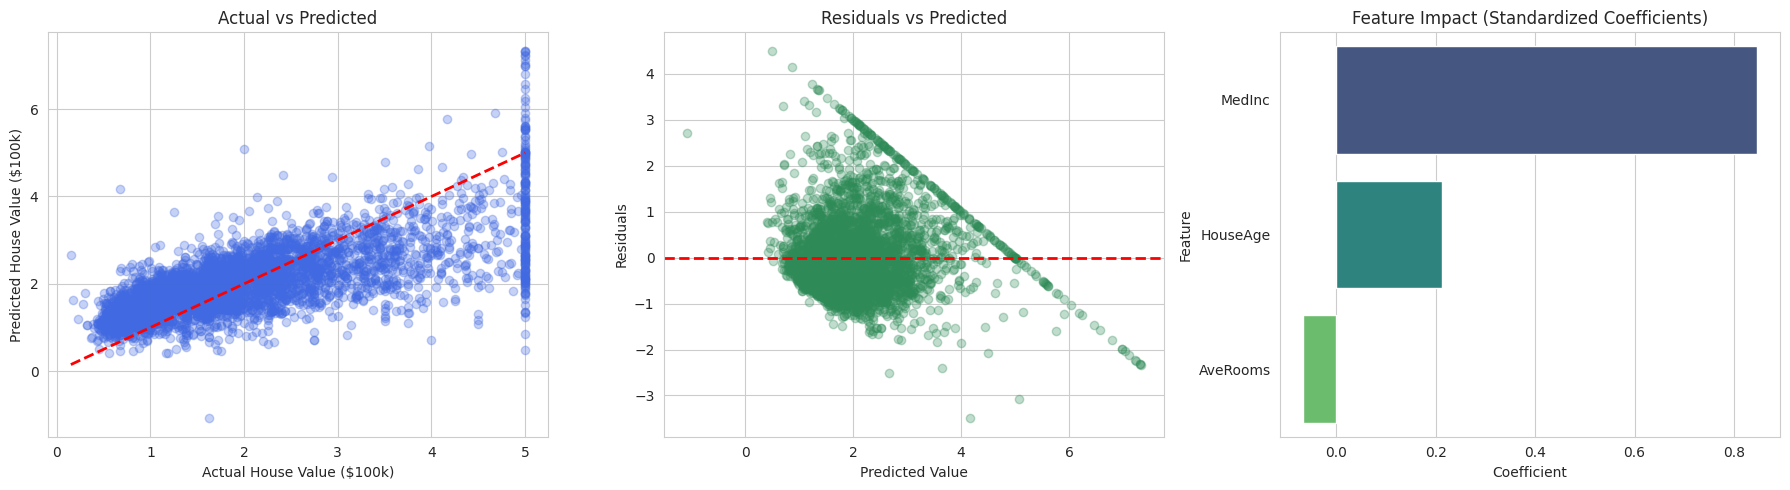

Regression Coefficient Analysis:
- MedInc: Strong positive impact (0.8469). As MedInc increases, house value tends to increase.
- HouseAge: Strong positive impact (0.2122). As HouseAge increases, house value tends to increase.
- AveRooms: Strong negative impact (-0.0672). As AveRooms increases, house value tends to increase.


"\nDiscussion:\n1. Decision Making: This model provides a baseline for real estate valuation. \n   Policy makers could use MedInc coefficients to understand how neighborhood \n   wealth drives property tax revenue.\n   \n2. Model Plausibility: While the linear model captures the general trend, the \n   Actual vs. Predicted plot shows a 'ceiling effect' at 5.0 (due to dataset \n   clipping). A linear assumption is partially plausible but misses geographical \n   nuances.\n\n3. Limitations & Safety: It is unsafe to infer causality (e.g., simply adding \n   rooms doesn't guarantee a price hike). Omitted variables like proximity to \n   the coast or local crime rates mean this model should be used as a \n   starting point, not a final appraisal tool.\n"

In [19]:
# TODO: implement here
# Create complete regression analysis:
# --- Visualizations ---
plt.figure(figsize=(18, 5))

# 1. Actual vs Predicted Values
plt.subplot(1, 3, 1)
plt.scatter(y_test_c, y_pred_np_custom, alpha=0.3, color='royalblue')
plt.plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], 'r--', lw=2)
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Actual vs Predicted')

# 2. Residuals Plot
plt.subplot(1, 3, 2)
residuals_c = y_test_c.values - y_pred_np_custom
plt.scatter(y_pred_np_custom, residuals_c, alpha=0.3, color='seagreen')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Value')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

# 3. Coefficient Importance
plt.subplot(1, 3, 3)
coef_df = pd.DataFrame({'Feature': features_custom, 'Coefficient': model_np_custom.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')
plt.title('Feature Impact (Standardized Coefficients)')

plt.tight_layout()
plt.show()

print("Regression Coefficient Analysis:")
for index, row in coef_df.iterrows():
    direction = "positive" if row['Coefficient'] > 0 else "negative"
    print(f"- {row['Feature']}: Strong {direction} impact ({row['Coefficient']:.4f}). "
          f"As {row['Feature']} increases, house value tends to increase.")

"""
Discussion:
1. Decision Making: This model provides a baseline for real estate valuation.
   Policy makers could use MedInc coefficients to understand how neighborhood
   wealth drives property tax revenue.

2. Model Plausibility: While the linear model captures the general trend, the
   Actual vs. Predicted plot shows a 'ceiling effect' at 5.0 (due to dataset
   clipping). A linear assumption is partially plausible but misses geographical
   nuances.

3. Limitations & Safety: It is unsafe to infer causality (e.g., simply adding
   rooms doesn't guarantee a price hike). Omitted variables like proximity to
   the coast or local crime rates mean this model should be used as a
   starting point, not a final appraisal tool.
"""